# RUV-scVI 模型测试：SCVIRUVWithDisease

参考 `testRUVVAE.ipynb` 的数据读取与可视化风格，测试 `model_scvi_ruv.py` 中的 `SCVIRUVWithDisease`：

- 结构：`z_bio`（生物 latent）+ `z_uv`（unwanted-variation latent）+ company embedding + 线性疾病效应 `W_group`
- 目标 1：输出 **UV 的 latent space**（`z_uv` + company embedding），看不同 company 是否被 UV 分支吸收
- 目标 2：查看 **disease effect**（`W_group` 线性效应，即 status/疾病对基因的 logFC 影响）


In [1]:
import os
import sys

import numpy as np
import pandas as pd
import torch
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "/home/junyichen/code/RUVAEDEG")
from model_scvi_ruv import SCVIRUVWithDisease

from sklearn.decomposition import PCA

print(f"torch {torch.__version__}, scanpy {sc.__version__}")


/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.12.1+cu126, scanpy 1.12.3


/tmp/ipykernel_3822490/1194474025.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"torch {torch.__version__}, scanpy {sc.__version__}")


## 1. 读取数据

与 `testRUVVAE.ipynb` 一致：读取 h5ad，筛选一个细胞类型（默认第二个最多），只保留 male。


In [2]:
DATA_PATH = "/data7/mark/STG/dataset/snRNA/merge_SCH_new/six_datasets_4v3_500_1000gene/TH_downsampled_ratio.h5ad"

adata = sc.read_h5ad(DATA_PATH)
print(f"原始 shape: {adata.shape}")

# 与 testRUVVAE.ipynb 一致：选第二多的细胞类型 + 只保留 male
celltype_counts = adata.obs["celltype.L2"].value_counts()
print("细胞类型分布:\n", celltype_counts.head(5))
adata_subset = adata[adata.obs["celltype.L2"].isin(celltype_counts.head(2).index[1:2])]
adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]

print(f"\nsubset shape: {adata_subset.shape}")
print(f"status 分布:\n{adata_subset.obs['status'].value_counts()}")
print(f"\ncompany 分布:\n{adata_subset.obs['company'].value_counts()}")


原始 shape: (201921, 16428)
细胞类型分布:
 celltype.L2
MOL-1                  23858
Astrocyte-1            21068
TH Tll1_Thsd7b Glut    19158
MOL-2                  18150
TH Tnc_Cdh20 Glut      16458
Name: count, dtype: int64

subset shape: (13885, 16428)
status 分布:
status
CSRES    3407
CUSUS    3049
CSSUS    2948
CON      2317
CURES    2164
Name: count, dtype: int64

company 分布:
company
beirui      10613
yunzhun      2281
seekgene      991
Name: count, dtype: int64


## 2. 数据准备：n_genes_on 协变量 + setup_anndata

`n_genes_on`（每个细胞 >0 的基因数，z-score 后作为连续技术协变量）与 `scVI.py` 一致。


In [3]:
# 计算 n_genes_on（与 scVI.py 一致）：>0 基因数，z-score
n_genes_on_raw = (adata_subset.layers["counts"] > 0).sum(axis=1).astype(np.float32)
n_genes_on_mean = float(n_genes_on_raw.mean())
n_genes_on_std = float(n_genes_on_raw.std())
adata_subset.obs["n_genes_on"] = (
    (n_genes_on_raw - n_genes_on_mean) / n_genes_on_std
).astype(np.float32)
print(f"n_genes_on mean/std: {n_genes_on_mean:.1f} / {n_genes_on_std:.1f}")

# counts 放回 X（scVI 需要 counts 数据）
adata_subset.X = adata_subset.layers["counts"].copy()

# company -> batch_key；status -> labels_key（线性疾病效应 W_group）
SCVIRUVWithDisease.setup_anndata(
    adata_subset,
    layer=None,
    batch_key="company",            # company embedding（仅进入 UV 分支）
    labels_key="status",            # 线性疾病效应 W_group
    categorical_covariate_keys=None,
    continuous_covariate_keys=["n_genes_on"],  # 技术协变量（进入 UV 分支）
)
print("✓ setup_anndata complete")


n_genes_on mean/std: 1537.8 / 451.2
✓ setup_anndata complete


/tmp/ipykernel_3822490/2940854715.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_subset.obs["n_genes_on"] = (


## 3. 训练 SCVIRUVWithDisease


In [4]:
torch.manual_seed(42)
np.random.seed(42)

model = SCVIRUVWithDisease(
    adata_subset,
    n_latent=32,          # z_bio 维度
    n_latent_uv=4,        # z_uv 维度（UV latent）
    uv_n_hidden=32,      # UV 分支隐藏层维度
    company_embed_dim=4,  # company embedding 维度
    n_layers=2,
    n_hidden=128,
    gene_likelihood="zinb",
    group_effect_scale=0.01,
    group_effect_prior=0.0,  # 可选：>0 对 W_group 加 L2 惩罚
)
print(model)
print(f"\nW_group shape: {tuple(model.module.W_group.shape)}  (n_status, n_genes)")

# 训练（GPU 优先；数据量小可 CPU）
# 注意：lr 不是 model.train() 的顶层参数（会传给 Lightning Trainer），
# 必须放在 plan_kwargs 里 —— plan_kwargs 会传给 scvi TrainingPlan，它才有 lr。
train_device = "gpu" if torch.cuda.is_available() else "cpu"
model.train(
    max_epochs=200,
    accelerator=train_device,
    devices=1,
    batch_size=512,
    plan_kwargs={"n_epochs_kl_warmup": 50, "lr": 1e-3},
)
print("✓ 训练完成")


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 32, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False



W_group shape: (5, 16428)  (n_status, n_genes)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A800 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/junyichen/anaconda3/envs/scvi-env/lib

Epoch 1/200:   0%|          | 0/200 [00:00<?, ?it/s]

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/torch/utils/data/_utils/collate.py:70: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.as_tensor(data)


Epoch 200/200: 100%|██████████| 200/200 [02:29<00:00,  1.34it/s, v_num=1, train_loss=4.73e+3]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [02:29<00:00,  1.34it/s, v_num=1, train_loss=4.73e+3]
✓ 训练完成


## 4. 输出 UV 的 latent space（z_uv + company embedding）

`z_uv` 是每个细胞的 unwanted-variation latent；company embedding 是每个 company 一个向量。两者都可以输出。


In [5]:
# 1) 每个细胞的 UV latent（后验均值）
z_uv = model.get_z_uv(adata_subset)
print(f"z_uv shape: {z_uv.shape}  (n_cells, n_latent_uv)")

# 2) 每个细胞的 bio latent（对照）
z_bio = model.get_z_bio(adata_subset)
print(f"z_bio shape: {z_bio.shape}  (n_cells, n_latent)")

# 3) company embedding（每个 company 一个向量）
company_emb_df = model.get_company_embedding()
print(f"\ncompany embedding ({company_emb_df.shape[0]} x {company_emb_df.shape[1]}):")
print(company_emb_df)

# 存回 obs，方便可视化
adata_subset.obs["company_str"] = adata_subset.obs["company"].astype(str)
adata_subset.obsm["X_z_bio"] = z_bio
adata_subset.obsm["X_z_uv"] = z_uv


z_uv shape: (13885, 4)  (n_cells, n_latent_uv)
z_bio shape: (13885, 32)  (n_cells, n_latent)

company embedding (3 x 4):
                 0         1         2         3
beirui    0.930551 -1.028828  2.539026  2.167245
seekgene  1.197103 -1.422528  1.930960  0.619220
yunzhun  -0.317840 -1.936681 -0.080294  2.353136


## 5. 可视化 latent space

- 左：`z_uv` 的 PCA，按 company 着色 —— UV 分支应把不同 company 分开（公司信息进了 UV，不进 bio）
- 右：`z_bio` 的 PCA，按 status 着色 —— 生物 latent 保留疾病差异


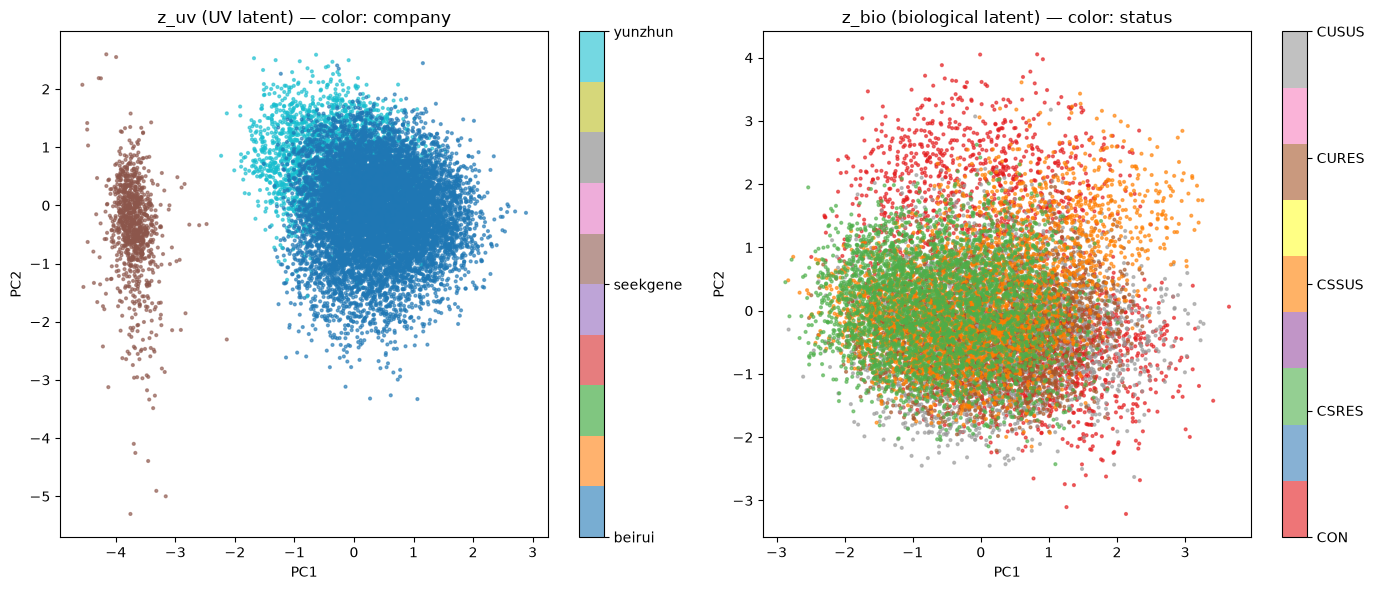

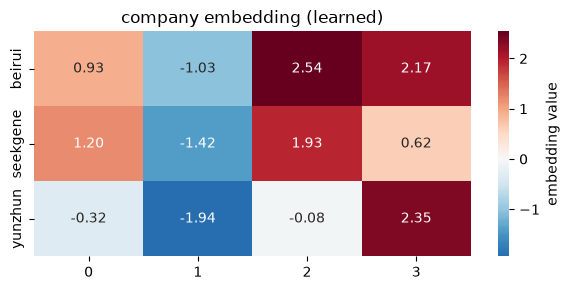

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- z_uv PCA（按 company 着色） ---
uv_pca = PCA(n_components=2).fit_transform(z_uv)
sc1 = axes[0].scatter(uv_pca[:, 0], uv_pca[:, 1],
                      c=adata_subset.obs["company"].astype("category").cat.codes,
                      cmap="tab10", s=4, alpha=0.6)
axes[0].set_title("z_uv (UV latent) — color: company")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
cbar1 = plt.colorbar(sc1, ax=axes[0], ticks=range(adata_subset.obs["company"].nunique()))
cbar1.set_ticklabels(adata_subset.obs["company"].astype("category").cat.categories)

# --- z_bio PCA（按 status 着色） ---
bio_pca = PCA(n_components=2).fit_transform(z_bio)
sc2 = axes[1].scatter(bio_pca[:, 0], bio_pca[:, 1],
                      c=adata_subset.obs["status"].astype("category").cat.codes,
                      cmap="Set1", s=4, alpha=0.6)
axes[1].set_title("z_bio (biological latent) — color: status")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
cbar2 = plt.colorbar(sc2, ax=axes[1], ticks=range(adata_subset.obs["status"].nunique()))
cbar2.set_ticklabels(adata_subset.obs["status"].astype("category").cat.categories)

plt.tight_layout()
plt.show()

# --- company embedding 热图 ---
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(company_emb_df, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            ax=ax, cbar_kws={"label": "embedding value"})
ax.set_title("company embedding (learned)")
plt.tight_layout()
plt.show()


/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


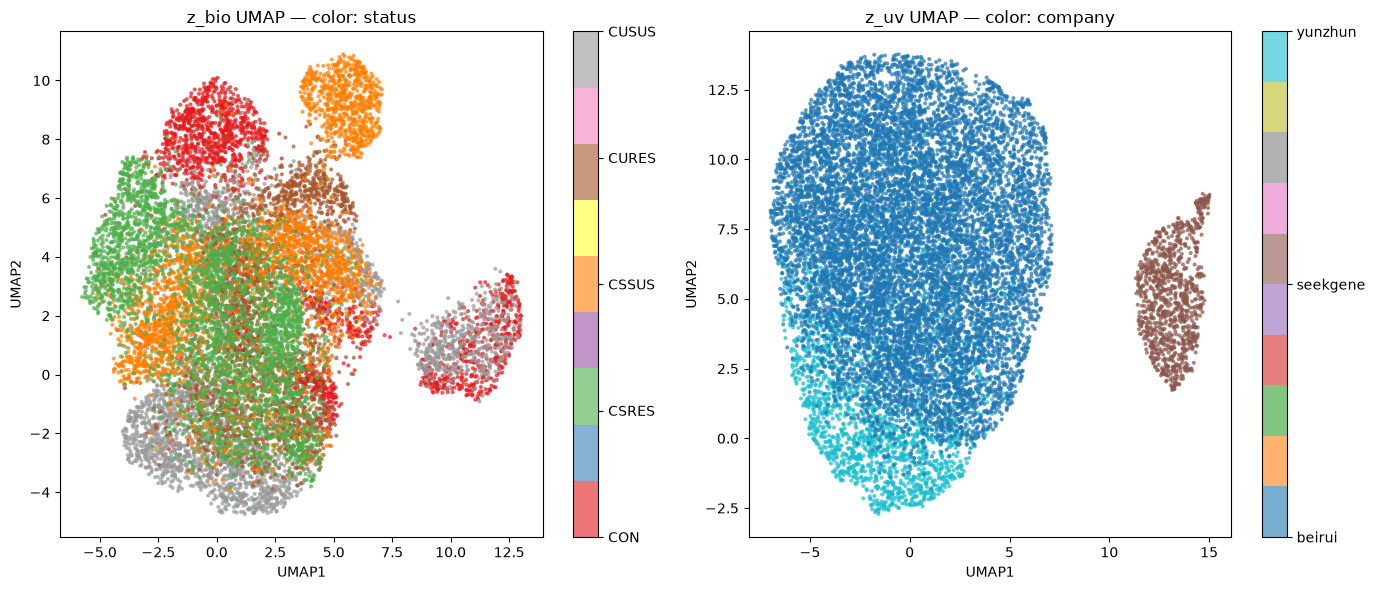

In [12]:
# --- 5b. UMAP 可视化（z_bio / z_uv） ---
# 用 scanpy 的 umap（内部自动选 annoy / pynndescent）。
# 先存到临时 AnnData 跑 umap，避免改动 adata_subset。

def plot_umap(latent, obs_col, title, cmap, ax):
    """对 latent 跑 UMAP 并在 ax 上按 obs_col 着色。"""
    tmp = sc.AnnData(X=latent, obs=adata_subset.obs[[obs_col]].copy())
    sc.pp.neighbors(tmp, n_neighbors=15, use_rep="X", n_pcs=None)
    sc.tl.umap(tmp)
    umap_coords = tmp.obsm["X_umap"]
    codes = tmp.obs[obs_col].astype("category").cat.codes
    cats = tmp.obs[obs_col].astype("category").cat.categories
    sc_ = ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
                     c=codes, cmap=cmap, s=4, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    cbar = plt.colorbar(sc_, ax=ax, ticks=range(len(cats)))
    cbar.set_ticklabels(cats)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# z_bio UMAP：按 status 着色（疾病差异应在 bio latent）
plot_umap(z_bio, "status", "z_bio UMAP — color: status", "Set1", axes[0])

# z_uv UMAP：按 company 着色（公司差异应在 UV latent）
plot_umap(z_uv, "company", "z_uv UMAP — color: company", "tab10", axes[1])

plt.tight_layout()
plt.show()


## 6. Disease effect：线性 W_group

`W_group` 是 (n_status, n_genes) 的线性疾病效应矩阵（在 log-rate 上，即乘性 `exp(W_group)`）。

- `W_group[disease] - W_group[control]` 就是疾病相对对照的 **logFC**
- `get_disease_logfc_by_group` 返回所有 status vs 对照的 logFC 表


In [7]:
# 所有 status vs CON 的线性疾病效应（logFC，基因 x status）
lfc_df = model.get_disease_logfc_by_group(control_group="CON")
print(f"lfc_df shape: {lfc_df.shape}  列: {list(lfc_df.columns[:4])}...")
lfc_df.head(3)

# 查看每个 status 的效应幅度（|logFC| 均值）
lfc_cols = [c for c in lfc_df.columns if c.startswith("logFC_")]
print("\n各 status 线性疾病效应平均 |logFC|:")
print(lfc_df[lfc_cols].abs().mean().sort_values(ascending=False))


lfc_df shape: (16428, 6)  列: ['gene', 'logFC_CON_vs_CON', 'logFC_CSRES_vs_CON', 'logFC_CSSUS_vs_CON']...

各 status 线性疾病效应平均 |logFC|:
logFC_CURES_vs_CON    0.137961
logFC_CSRES_vs_CON    0.137672
logFC_CSSUS_vs_CON    0.123470
logFC_CUSUS_vs_CON    0.111664
logFC_CON_vs_CON      0.000000
dtype: float32


## 7. Disease effect 可视化

1. 每个 status vs CON 的 logFC 分布（密度图）
2. 以 CURES vs CON 为例画 volcano（logFC 是线性效应，直接来自 W_group）


/tmp/ipykernel_3822490/1883749515.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(lfc_df[col], label=col, ax=ax)


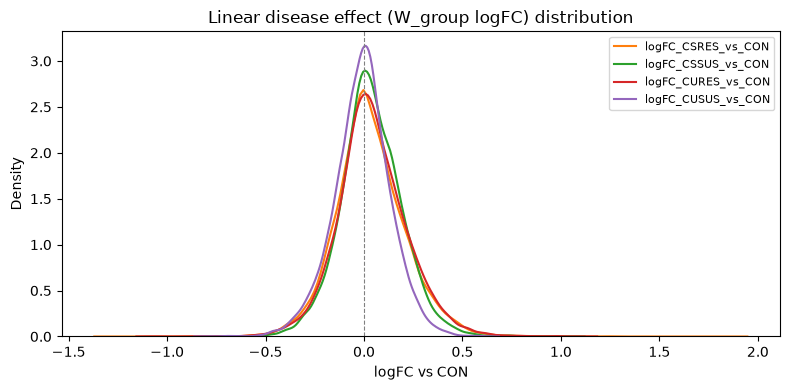

CURES vs CON 线性疾病效应 top20 基因:


,gene,logFC_CURES_vs_CON
3846,Rsrp1,1.107203
15198,Smim3,-1.078952
11841,Gm20751,1.064268
8757,Abhd14b,1.047672
8322,Zbtb16,-1.046287
2586,Paqr6,0.982646
10409,Pipox,0.979499
5962,Leng8,0.977627
3917,Padi2,0.976875
11748,Hist1h1c,0.951066


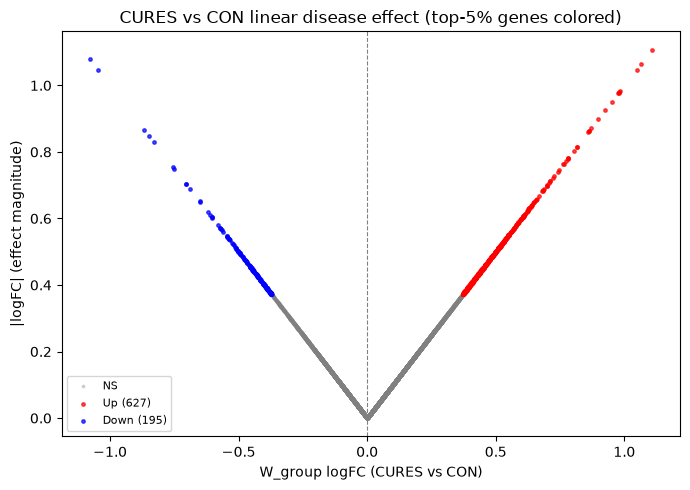

In [8]:
# --- 7a. 各 status 的 logFC 分布 ---
fig, ax = plt.subplots(figsize=(8, 4))
for col in lfc_cols:
    sns.kdeplot(lfc_df[col], label=col, ax=ax)
ax.axvline(0, c="gray", ls="--", lw=0.8)
ax.set_title("Linear disease effect (W_group logFC) distribution")
ax.set_xlabel("logFC vs CON"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# --- 7b. 以 CURES vs CON 为例：|logFC| top 20 基因 ---
top_lfc = lfc_df.assign(abs_lfc=lfc_df["logFC_CURES_vs_CON"].abs()) \
    .sort_values("abs_lfc", ascending=False).head(20)
print("CURES vs CON 线性疾病效应 top20 基因:")
display(top_lfc[["gene", "logFC_CURES_vs_CON"]])

# --- 7c. volcano：CURES vs CON ---
fig, ax = plt.subplots(figsize=(7, 5))
logfc = lfc_df["logFC_CURES_vs_CON"].values
# 线性效应没有 p-value；用 |logFC| 幅度作为"显著性"代理
threshold = np.percentile(np.abs(logfc), 95)
up = logfc > threshold
down = logfc < -threshold
ax.scatter(logfc[~up & ~down], np.abs(logfc[~up & ~down]), s=3, alpha=0.3, c="gray", label="NS")
ax.scatter(logfc[up], np.abs(logfc[up]), s=6, alpha=0.7, c="red", label=f"Up ({up.sum()})")
ax.scatter(logfc[down], np.abs(logfc[down]), s=6, alpha=0.7, c="blue", label=f"Down ({down.sum()})")
ax.axvline(0, c="gray", ls="--", lw=0.8)
ax.set_xlabel("W_group logFC (CURES vs CON)")
ax.set_ylabel("|logFC| (effect magnitude)")
ax.set_title(f"CURES vs CON linear disease effect (top-5% genes colored)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 8. 检查：UV 是否只吸收 company / 技术变异，而 disease 留在 bio 分支

理想行为：

- `z_uv` 的分布与 **company** 高度相关（company 差异被 UV 吸收）
- `z_bio` 的分布与 **status** 相关（疾病差异留在生物 latent）


In [9]:
from scipy.stats import f_oneway

obs = adata_subset.obs

# 用 ANOVA 量化：latent 与 company / status 的相关性
def anova_f(latent, groups):
    """对 latent 每一维做 ANOVA，返回平均 F 值（越大 = 组间差异越强）"""
    fs = []
    for d in range(latent.shape[1]):
        groups_list = [latent[groups == g, d] for g in np.unique(groups)]
        if len(groups_list) > 1:
            f, _ = f_oneway(*groups_list)
            fs.append(f)
    return np.mean(fs) if fs else np.nan

print("=== ANOVA F 值（越大 = 该 latent 与该分组越相关） ===")
print(f"{'latent':<10} {'~company':>10} {'~status':>10}")
print("-" * 32)
for name, latent in [("z_uv", z_uv), ("z_bio", z_bio)]:
    f_company = anova_f(latent, obs["company"].values)
    f_status = anova_f(latent, obs["status"].values)
    print(f"{name:<10} {f_company:>10.1f} {f_status:>10.1f}")

print("\n预期（健康模型）：")
print("  z_uv  ~company 高，~status 低  → company 差异进了 UV")
print("  z_bio ~status 高，~company 低  → 疾病差异留在生物 latent")


=== ANOVA F 值（越大 = 该 latent 与该分组越相关） ===
latent       ~company    ~status
--------------------------------
z_uv           7223.8      364.2
z_bio           666.6      201.0

预期（健康模型）：
  z_uv  ~company 高，~status 低  → company 差异进了 UV
  z_bio ~status 高，~company 低  → 疾病差异留在生物 latent


## 9. 重建质量检查

`get_reconstruction_parts` 返回 `(mu_scvi, mu_disease)`：`mu_scvi` 是 scVI 部分重建（bio + UV），`mu_disease = exp(W_group[status])` 是疾病乘性因子。


mu_scvi:   (13885, 16428)  范围 [0.00, 54378.69]
mu_disease: (13885, 16428)  范围 [0.3683, 2.3877]
mu_total:  (13885, 16428)

mu_disease 分布（exp(W_group)，1=无效应）:
  mean=0.9551, std=0.1043


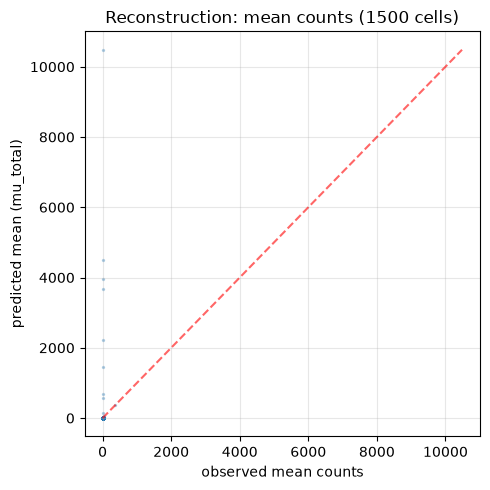

Spearman rho = 0.899 (p=0.00e+00)  — 越接近 1 重建越好


In [10]:
# 重建均值（每个细胞 x 基因）
mu_scvi, mu_disease = model.get_reconstruction_parts(adata_subset, batch_size=512)
mu_total = mu_scvi * mu_disease
print(f"mu_scvi:   {mu_scvi.shape}  范围 [{mu_scvi.min():.2f}, {mu_scvi.max():.2f}]")
print(f"mu_disease: {mu_disease.shape}  范围 [{mu_disease.min():.4f}, {mu_disease.max():.4f}]")
print(f"mu_total:  {mu_total.shape}")

# 疾病乘性因子的范围（应围绕 1，即大部分基因无疾病效应）
print(f"\nmu_disease 分布（exp(W_group)，1=无效应）:")
print(f"  mean={mu_disease.mean():.4f}, std={mu_disease.std():.4f}")

# 抽样检查重建质量（用 counts 的均值-方差对比，简化版）
counts = adata_subset.layers["counts"].toarray() if hasattr(adata_subset.layers["counts"], "toarray") else np.asarray(adata_subset.layers["counts"])
obs_mean = counts.mean(0)
pred_mean = mu_total.mean(0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(obs_mean, pred_mean, s=2, alpha=0.3)
lim = [0, max(obs_mean.max(), pred_mean.max())]
ax.plot(lim, lim, "r--", alpha=0.6)
ax.set_xlabel("observed mean counts"); ax.set_ylabel("predicted mean (mu_total)")
ax.set_title("Reconstruction: mean counts (1500 cells)"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

from scipy.stats import spearmanr
rho, p = spearmanr(obs_mean, pred_mean)
print(f"Spearman rho = {rho:.3f} (p={p:.2e})  — 越接近 1 重建越好")


## 10. 保存结果

把 latent 和 disease effect 存回 h5ad / csv 供后续分析。


In [11]:
OUT_PREFIX = "/home/junyichen/code/RUVAEDEG/scviRUV_output"

# latent 写回 adata
adata_subset.obsm["X_scVI_bio"] = z_bio
adata_subset.obsm["X_scVI_uv"] = z_uv
adata_subset.obsm["X_scVI_recon_mean"] = mu_total
adata_subset.layers["scvi_ruv_mu_disease"] = mu_disease

# disease effect 表
lfc_df.to_csv(OUT_PREFIX + ".disease_effect.csv", index=False)
print(f"✓ saved: {OUT_PREFIX}.disease_effect.csv")

# company embedding
company_emb_df.to_csv(OUT_PREFIX + ".company_embedding.csv")
print(f"✓ saved: {OUT_PREFIX}.company_embedding.csv")

# 保存模型（scvi 原生 save/load）
# model.save(OUT_PREFIX + ".model/")
# print(f"✓ saved: {OUT_PREFIX}.model/")


✓ saved: /home/junyichen/code/RUVAEDEG/scviRUV_output.disease_effect.csv
✓ saved: /home/junyichen/code/RUVAEDEG/scviRUV_output.company_embedding.csv
